# The reviewer-study figures (appendix)

One figure per study the NeurIPS reviews asked for: dataset-level over-parameterisation
(*P > N*), batch-size sensitivity, the residual exponent kappa, the memory knobs
(micro-batching and parameter fraction), the tuning-budget disclosure and the divergence
accounting.

## How this works

```python
f = pf.make('<figure>')          # draws it, writes NOTHING
f.show(zoom=2)                   # magnified screen copy (the PDF keeps its page size)
f.ax(0).set_ylabel('...')        # edit the matplotlib objects however you like
f.fig.set_size_inches(5.5, 2.4)  # f.axes = the builder's layout, f.flat = every panel
f.save()                         # writes iclr_manuscript/figures_iclr/<group>/<figure>.pdf,
                                 # the PNG twin and the provenance sidecar -- exactly as
                                 # `python -m paper_assets` does
```

Two kinds of option:

* **the figure's own knobs** — what it draws (methods, scans, panels), its geometry
  (`fraction`, `aspect`), line weights, legend placement. `pf.info('<figure>')` lists them
  with their defaults.
* **the generic cosmetics**, on every figure: `figsize`, `xlabel`, `ylabel`, `title`,
  `xlim`, `ylim`, `xscale`, `yscale`, `legend`, `suptitle`, `grid`, `tick_labelsize`,
  `rc`. Each takes a value for all panels, a list by panel position, or a dict keyed by
  panel index — e.g. `ylabel={0: 'Validation loss'}`, `legend={'loc': 'lower left',
  'ncol': 6, 'fontsize': 5}`.

Pass either to `pf.make(...)` for a one-off, or **pin** it so the paper build draws it
that way too:

```python
pf.pin('headline_curves', methods='all', aspect=0.95)   # -> paper_assets/figure_overrides.yaml
pf.rebuild('headline_curves')                           # draw with the pinned options + save
pf.unpin('headline_curves')                             # back to the builder's default
```

Pinned options live in `analysis/paper_assets/figure_overrides.yaml`, which
`python -m paper_assets` reads, so a full rebuild reproduces your version instead of
reverting it. Nothing in this notebook writes until you call `save()` or `rebuild()`, so
re-running it top to bottom is safe.

**A note on size.** These are drawn at their true size on the page (a 0.32-linewidth
panel is 1.76 in wide, 7 pt type), so they look small inline; `show(zoom=...)` only
magnifies the screen copy. To judge the type size, look at the PNG twin under
`agent_lab/paper_assets/<group>/` after saving — it is written at the physical size.

In [1]:
%matplotlib inline
import os
import sys

# This notebook lives in analysis/notebooks/paper/, but every analysis path is
# relative to analysis/ (plots_v2/, tables/, ../experiment_results), so run from there
# with the helper modules in analysis/lib/ on the path.
_A = os.getcwd()
while not all(os.path.isdir(os.path.join(_A, d)) for d in ('lib', 'notebooks')):
    _A, _prev = os.path.dirname(_A), _A
    if _A == _prev:
        raise RuntimeError('analysis/ not found above ' + os.getcwd())
os.chdir(_A)
sys.path.insert(0, _A)
sys.path.insert(0, os.path.join(_A, 'lib'))

import paper_assets.notebook as pf

pf.figures('reviewer')

,figure,group,module,knobs,pinned,what
0,batchsize,reviewer,reviewer,"arm_tick_fmt, aspect, batch_sizes, cap_line, c...",-,"F6: batch-size sweep -- selection, used rank v..."
1,budget,reviewer,reviewer,"annotate_equal_budget, annotation_fontsize, as...",-,"F4: best-of-n tuning curves on two grids, with..."
2,divergence,reviewer,reviewer,"aspect, dot_ms, extra_h, fraction, legend_belo...",-,F10: where Sven diverges -- by rtol on the wor...
3,divergence_grids,reviewer,reviewer,"aspect, cell_fontsize, counts_only, extra_h, f...",-,"F10b: the per-grid (rtol, eta) divergence maps..."
4,kappa,reviewer,reviewer,"arm_tick_fmt, aspect, capsize, default_kappa_l...",-,"F8: kappa at matched effective step -- loss, s..."
5,knobs,reviewer,reviewer,"arm_tick_fmt, aspect, cap_line, cap_lw, extra_...",-,F14: micro-batching and parameter masking -- q...
6,overparam,reviewer,reviewer,"arm_tick_fmt, aspect, extra_h, fraction, legen...",-,F5: the P/N sweep -- selected val. loss per ta...
7,overparam_outcomes,reviewer,reviewer,"arm_tick_fmt, aspect, extra_h, fraction, legen...",-,F5b: the same sweep read on test loss and on f...


## `batchsize`

F6: batch-size sweep -- selection, used rank vs the cap, cost, divergence

Its own knobs:

* `arm_tick_fmt` — default `'{:.0f}'`
* `aspect` — default `0.8`
* `batch_sizes` — default `[]`
* `cap_line` — default `True`
* `cmap` — default `'viridis'`
* `cost_legend` — default `{'fontsize': 5.4, 'loc': 'upper left', 'handlelength': 1.1}`
* `extra_h` — default `0.55`
* `fraction` — default `0.49`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 5, 'height': 0.55, 'fontsize': 5.6}`
* `memory_axis` — default `True`
* `memory_color` — default `'#B35806'`
* `memory_labelsize` — default `5.6`
* `ms` — default `2.4`
* `ncol` — default `2`
* `nrow` — default `2`
* `only_diverging_methods` — default `True`
* `other_lw` — default `0.75`
* `overlay_ms` — default `2.0`
* `rank_legend` — default `{'fontsize': 5.4, 'loc': 'upper left', 'handlelength': 1.1, 'ncol': 1}`
* `rtol_lw` — default `0.9`
* `rtol_ms` — default `2.2`
* `style_fraction` — default `0.49`
* `sven_lw` — default `1.25`
* `thin_ms` — default `2.2`


Loaded 3060 runs from ../experiment_results/_cache/rebuttal_batchsize_polynomial_scan.slim.pkl (slim cache)


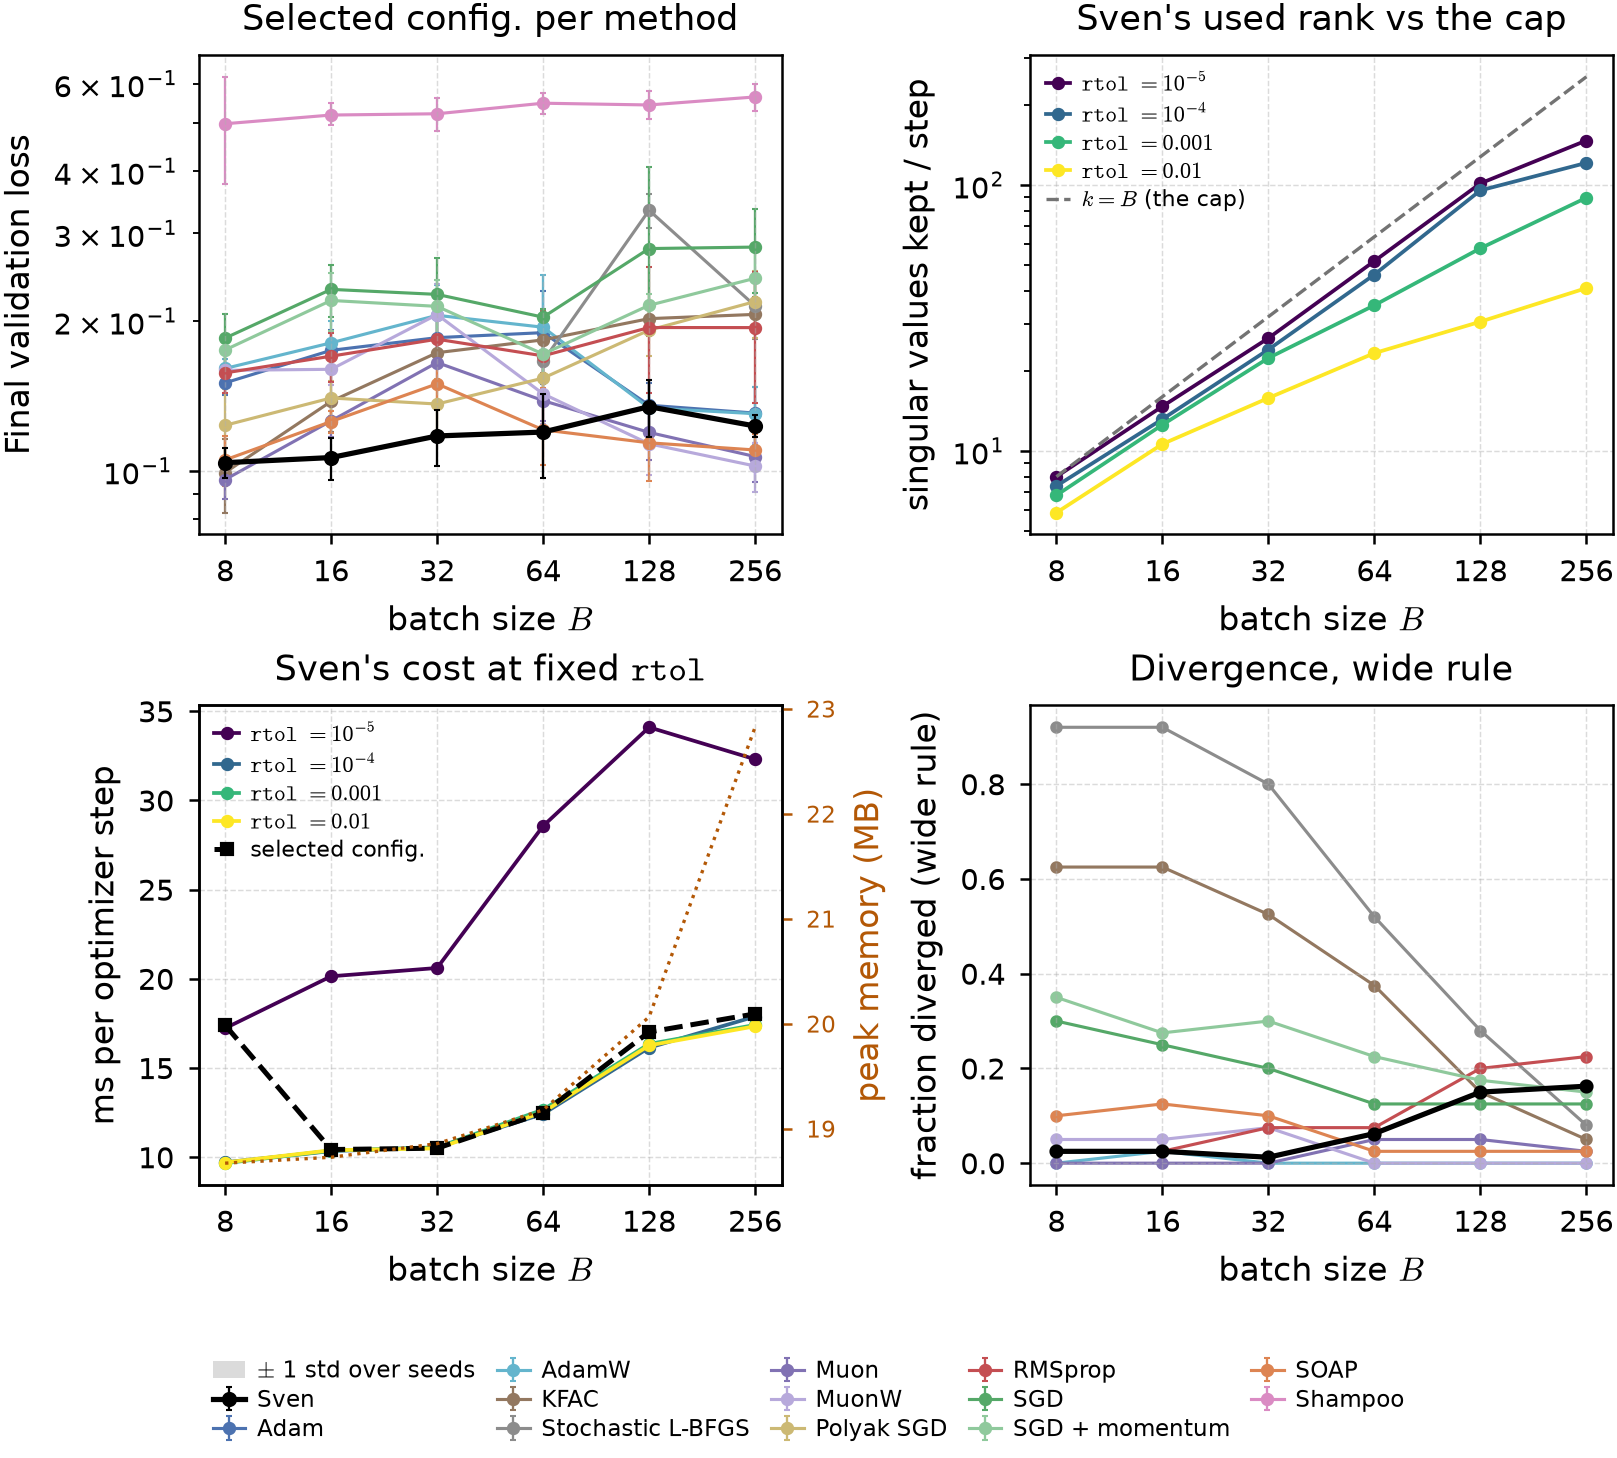

batchsize: 5.39 x 4.86 in on the page (shown at 2x)


In [2]:
f = pf.make('batchsize')
f.show(zoom=2)

In [3]:
# --- edit batchsize -------------------------------------------------------
# its own knobs: arm_tick_fmt, aspect, batch_sizes, cap_line, cmap, cost_legend, extra_h, fraction, legend_below, memory_axis, memory_color, memory_labelsize, ms, ncol, nrow, only_diverging_methods, other_lw, overlay_ms, rank_legend, rtol_lw, rtol_ms, style_fraction, sven_lw, thin_ms
# f = pf.make('batchsize', arm_tick_fmt='{:.0f}', aspect=0.8, batch_sizes=[])
# f = pf.make('batchsize', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('batchsize', aspect=0.95)              # ... and make the CLI agree

## `budget`

F4: best-of-n tuning curves on two grids, with the equal-budget mark

Its own knobs:

* `annotate_equal_budget` — default `True`
* `annotation_fontsize` — default `5.4`
* `aspect` — default `0.82`
* `equal_budget_color` — default `'crimson'`
* `equal_budget_line` — default `True`
* `extra_h` — default `0.62`
* `fraction` — default `0.49`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 5, 'height': 0.62, 'fontsize': 5.4}`
* `legend_lw` — default `0.9`
* `methods` — default `[]`
* `nrow` — default `1`
* `other_lw` — default `0.7`
* `panels` — default `['polynomial_scan', 'mnist_scan_labelRegression']`
* `style_fraction` — default `0.49`
* `sven_lw` — default `1.3`
* `thin_ms` — default `2.2`


Loaded 1770 runs from ../experiment_results/_cache/toy_1d_scan.slim.pkl (slim cache)


Loaded 1630 runs from ../experiment_results/_cache/polynomial_scan.slim.pkl (slim cache)


Loaded 1360 runs from ../experiment_results/_cache/mnist_scan_labelRegression.slim.pkl (slim cache)


Loaded 1610 runs from ../experiment_results/_cache/mnist_scan_ce.slim.pkl (slim cache)


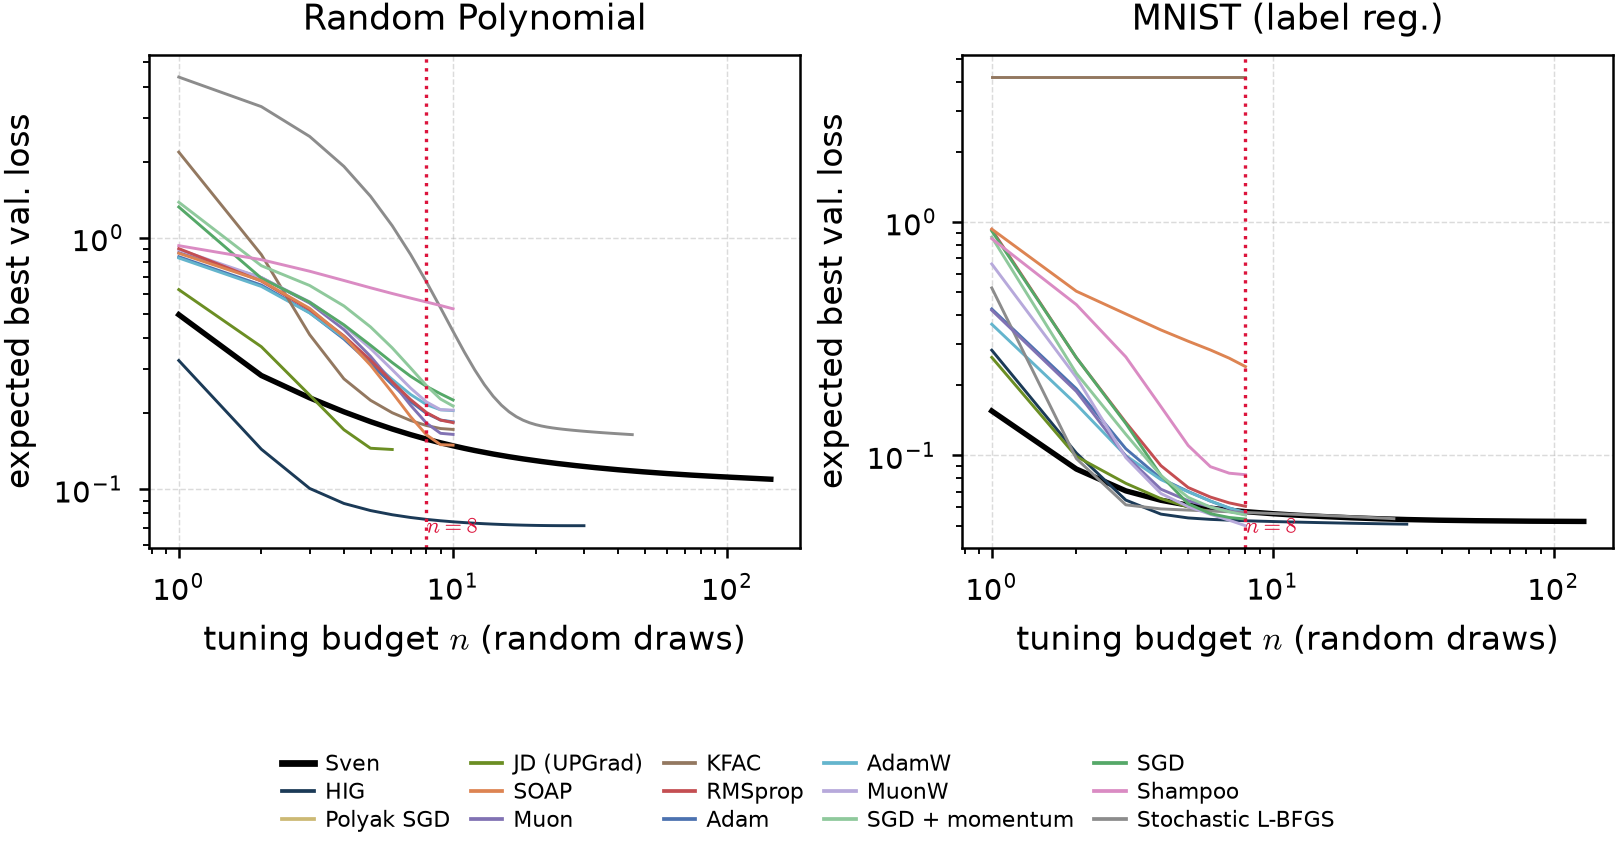

budget: 5.39 x 2.83 in on the page (shown at 2x)


In [4]:
f = pf.make('budget')
f.show(zoom=2)

In [5]:
# --- edit budget -------------------------------------------------------
# its own knobs: annotate_equal_budget, annotation_fontsize, aspect, equal_budget_color, equal_budget_line, extra_h, fraction, legend_below, legend_lw, methods, nrow, other_lw, panels, style_fraction, sven_lw, thin_ms
# f = pf.make('budget', annotate_equal_budget=True, annotation_fontsize=5.4, aspect=0.82)
# f = pf.make('budget', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('budget', aspect=0.95)              # ... and make the CLI agree

## `divergence`

F10: where Sven diverges -- by rtol on the worst grids, and by method

Its own knobs:

* `aspect` — default `0.86`
* `dot_ms` — default `2.6`
* `extra_h` — default `0.62`
* `fraction` — default `0.49`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 3, 'height': 0.62, 'fontsize': 5.2}`
* `lw` — default `1.0`
* `max_grids` — default `6`
* `method_labelsize` — default `5.2`
* `ms` — default `2.4`
* `ncol` — default `2`
* `nrow` — default `1`
* `panel_legend` — default `{'fontsize': 4.8, 'loc': 'lower right', 'handlelength': 0.8, 'markerscale': 1.2}`
* `scan_offset` — default `0.16`
* `scans` — default `['toy_1d_scan', 'polynomial_scan', 'mnist_scan_labelRegression', 'mnist_scan_ce']`
* `style_fraction` — default `0.49`


Loaded 785 runs from ../experiment_results/_cache/cifar10_resnet_ce_scan.slim.pkl (slim cache)


Loaded 600 runs from ../experiment_results/_cache/cifar10_resnet_scan_labelRegression.slim.pkl (slim cache)
Loaded 29 runs from ../experiment_results/_cache/exp_gpt2_small_comparison.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/exp_nanogpt_speedrun.slim.pkl (slim cache)


Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_ce_scan.slim.pkl (slim cache)
Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_labelreg_scan.slim.pkl (slim cache)


Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)
Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)
Loaded 120 runs from ../experiment_results/_cache/polynomial_microbatch_scan.slim.pkl (slim cache)


Loaded 100 runs from ../experiment_results/_cache/polynomial_paramfrac_scan.slim.pkl (slim cache)


...

Loaded 30 runs from ../experiment_results/_cache/rebuttal_fig5_cifar_paramfrac_scan.slim.pkl (slim cache)


Loaded 3600 runs from ../experiment_results/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


Loaded 4320 runs from ../experiment_results/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)
Loaded 120 runs from ../experiment_results/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)


Loaded 100 runs from ../experiment_results/_cache/toy_1d_paramfrac_scan.slim.pkl (slim cache)


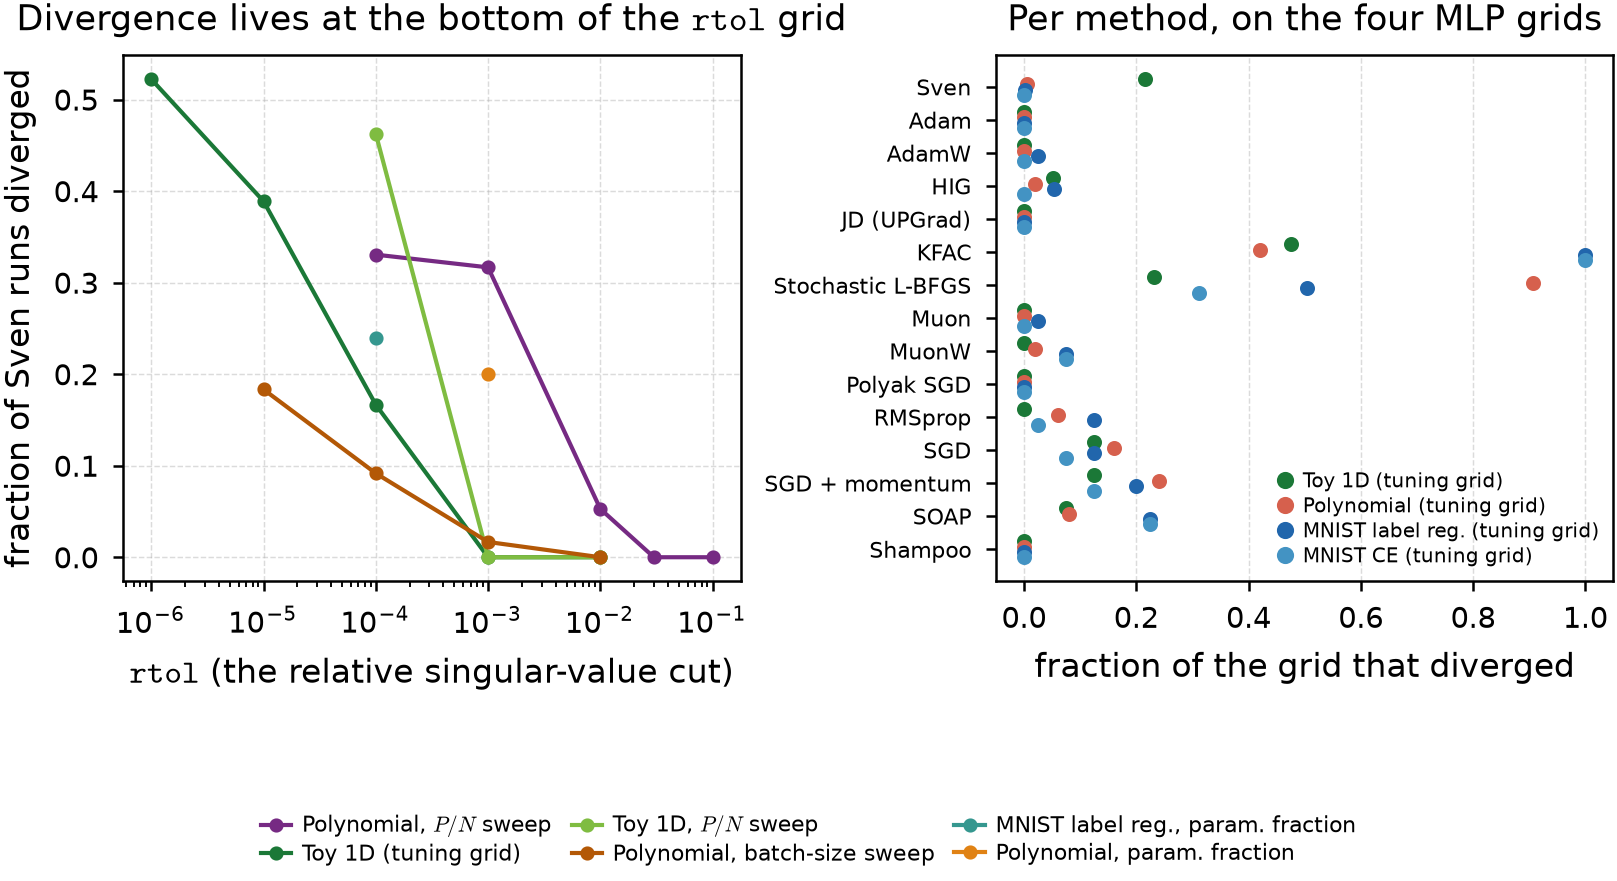

divergence: 5.39 x 2.94 in on the page (shown at 2x)


In [6]:
f = pf.make('divergence')
f.show(zoom=2)

In [7]:
# --- edit divergence -------------------------------------------------------
# its own knobs: aspect, dot_ms, extra_h, fraction, legend_below, lw, max_grids, method_labelsize, ms, ncol, nrow, panel_legend, scan_offset, scans, style_fraction
# f = pf.make('divergence', aspect=0.86, dot_ms=2.6, extra_h=0.62)
# f = pf.make('divergence', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('divergence', aspect=0.95)              # ... and make the CLI agree

## `divergence_grids`

F10b: the per-grid (rtol, eta) divergence maps, one panel per grid

Its own knobs:

* `aspect` — default `1.02`
* `cell_fontsize` — default `4.4`
* `counts_only` — default `True`
* `extra_h` — default `0.0`
* `fraction` — default `0.3333333333333333`
* `label_fontsize` — default `5.6`
* `max_grids` — default `6`
* `ncol` — default `3`
* `panel_ticksize` — default `4.6`
* `style_fraction` — default `0.32`
* `title_fontsize` — default `5.4`


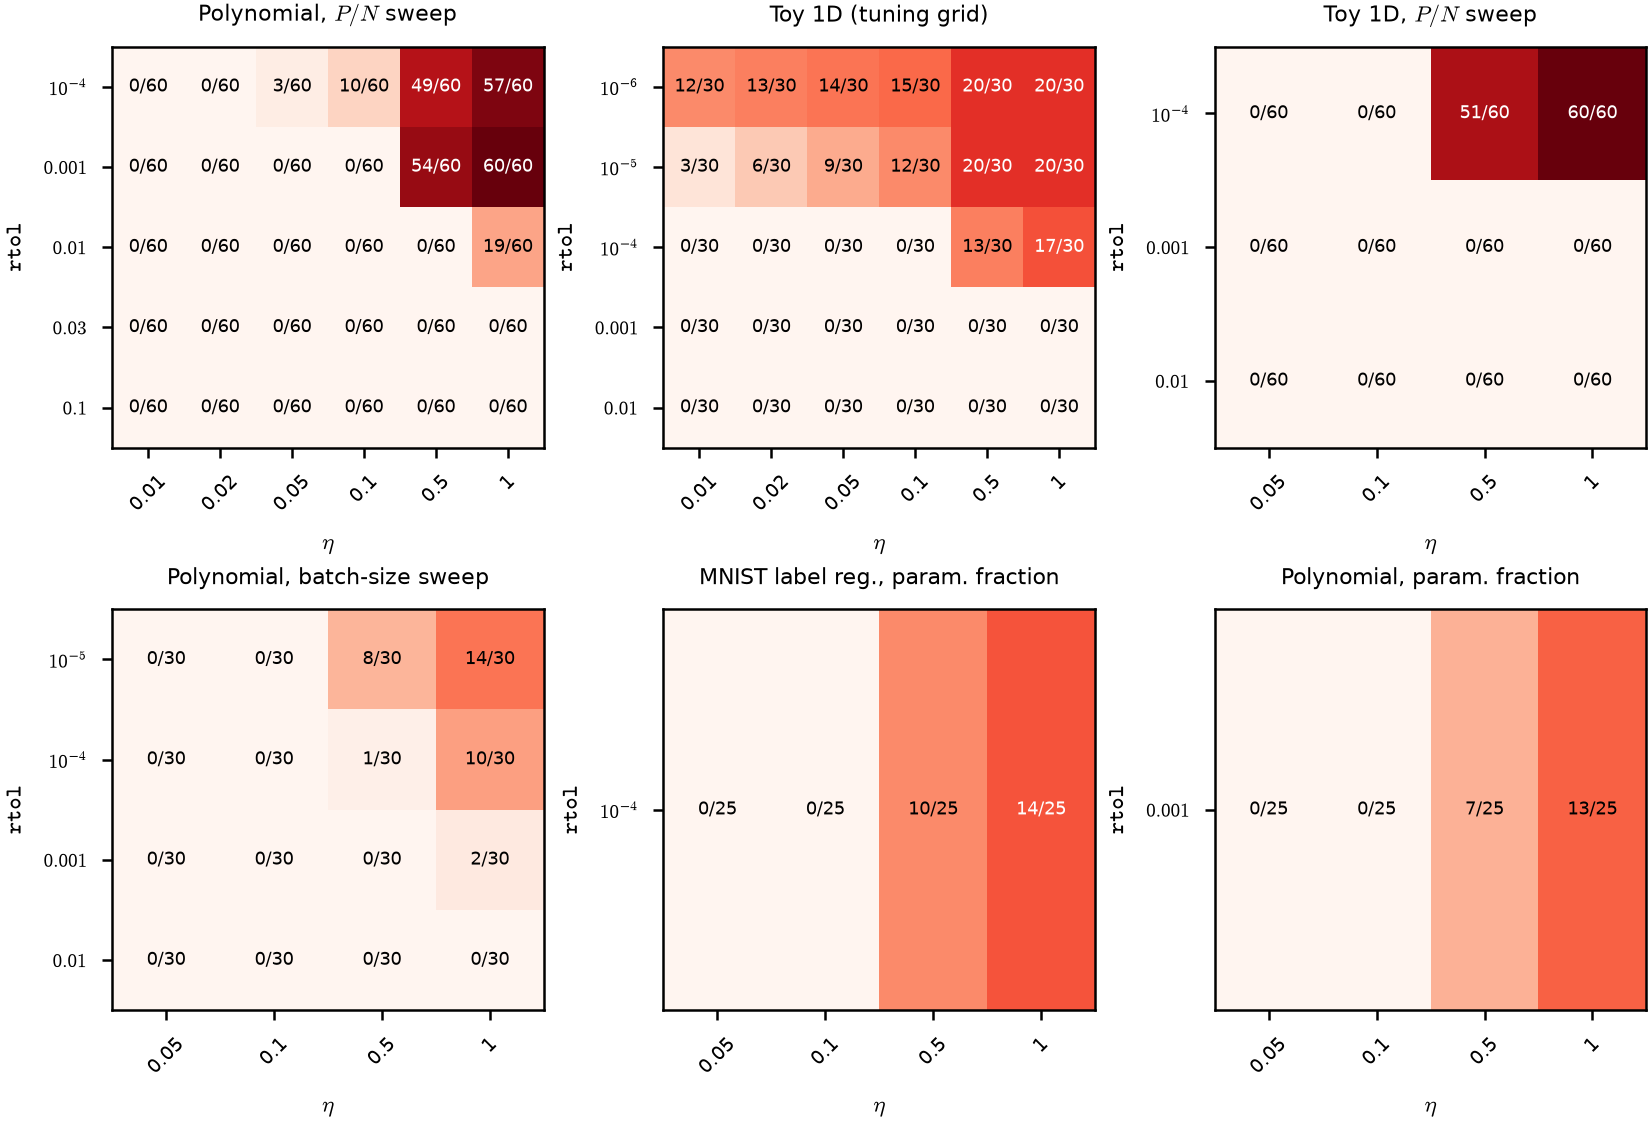

divergence_grids: 5.50 x 3.74 in on the page (shown at 2x)


In [8]:
f = pf.make('divergence_grids')
f.show(zoom=2)

In [9]:
# --- edit divergence_grids -------------------------------------------------------
# its own knobs: aspect, cell_fontsize, counts_only, extra_h, fraction, label_fontsize, max_grids, ncol, panel_ticksize, style_fraction, title_fontsize
# f = pf.make('divergence_grids', aspect=1.02, cell_fontsize=4.4, counts_only=True)
# f = pf.make('divergence_grids', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('divergence_grids', aspect=0.95)              # ... and make the CLI agree

## `kappa`

F8: kappa at matched effective step -- loss, spread over kappa, used rank

Its own knobs:

* `arm_tick_fmt` — default `'{:g}'`
* `aspect` — default `0.92`
* `capsize` — default `1.2`
* `default_kappa_lw` — default `1.2`
* `elinewidth` — default `0.5`
* `extra_h` — default `0.42`
* `fraction` — default `0.3333333333333333`
* `full_ls` — default `'-'`
* `kappas` — default `[]`
* `ks` — default `[]`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 6, 'height': 0.42, 'fontsize': 5.4}`
* `lw` — default `1.0`
* `mark_matched_steps` — default `True`
* `ms` — default `2.0`
* `ncol` — default `3`
* `nrow` — default `1`
* `other_lw` — default `0.8`
* `rank_lw` — default `0.9`
* `spread_ms` — default `2.2`
* `style_fraction` — default `0.32`
* `trunc_ls` — default `'--'`


Loaded 210 runs from ../experiment_results/_cache/mnist_kappaScan_labelRegression.slim.pkl (slim cache)


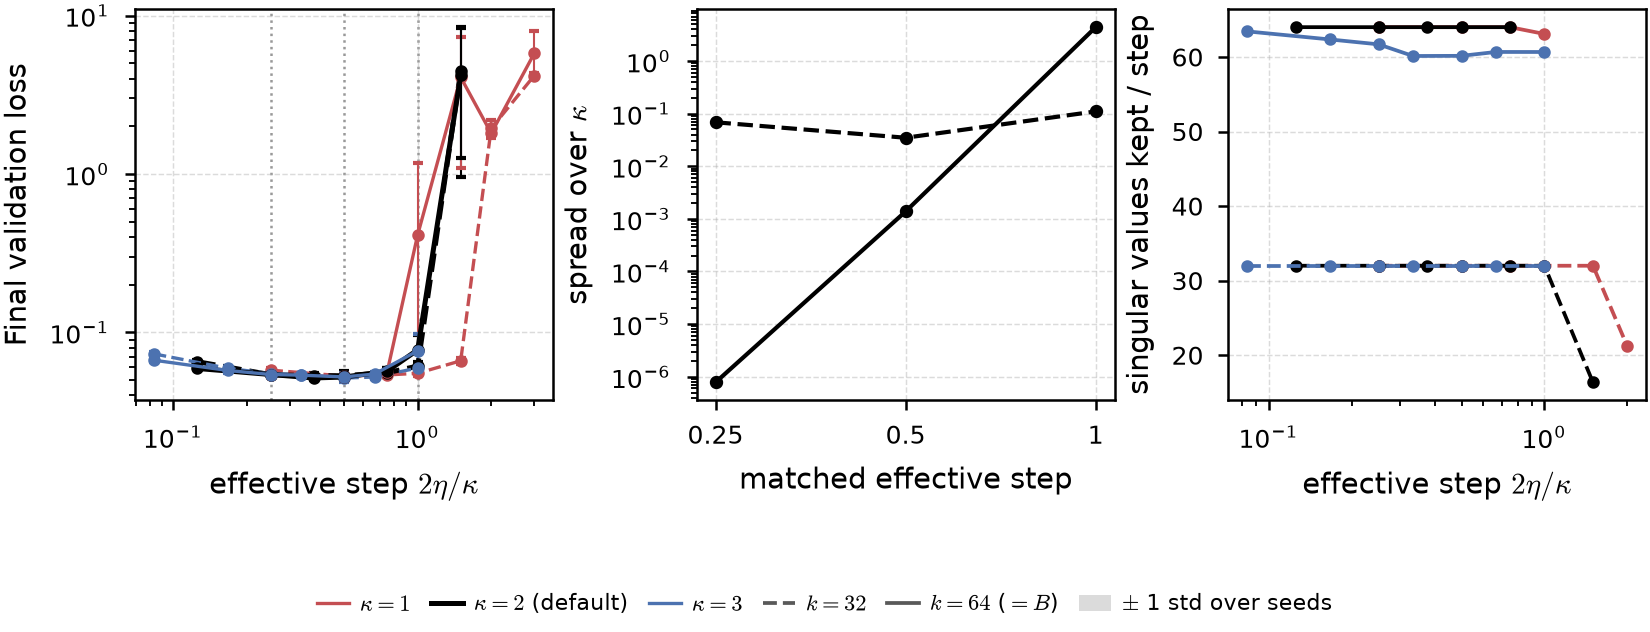

kappa: 5.50 x 2.11 in on the page (shown at 2x)


In [10]:
f = pf.make('kappa')
f.show(zoom=2)

In [11]:
# --- edit kappa -------------------------------------------------------
# its own knobs: arm_tick_fmt, aspect, capsize, default_kappa_lw, elinewidth, extra_h, fraction, full_ls, kappas, ks, legend_below, lw, mark_matched_steps, ms, ncol, nrow, other_lw, rank_lw, spread_ms, style_fraction, trunc_ls
# f = pf.make('kappa', arm_tick_fmt='{:g}', aspect=0.92, capsize=1.2)
# f = pf.make('kappa', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('kappa', aspect=0.95)              # ... and make the CLI agree

## `knobs`

F14: micro-batching and parameter masking -- quality, used rank, step time

Its own knobs:

* `arm_tick_fmt` — default `'{:.0f}'`
* `aspect` — default `0.8`
* `cap_line` — default `True`
* `cap_lw` — default `0.7`
* `extra_h` — default `0.5`
* `family_proxies` — default `True`
* `fraction` — default `0.49`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 3, 'height': 0.5, 'fontsize': 5.6}`
* `lw` — default `1.0`
* `ms` — default `2.4`
* `ncol` — default `2`
* `nrow` — default `2`
* `reference_line` — default `True`
* `style_fraction` — default `0.49`
* `tasks` — default `['toy_1d', 'polynomial', 'mnist_labelreg', 'mnist_ce']`
* `time_lw` — default `0.9`
* `time_ms` — default `2.0`


Loaded 120 runs from ../experiment_results/_cache/toy_1d_microbatch_scan.slim.pkl (slim cache)


  [config_table] 20 configuration(s) with no result file at all (100 runs): ['svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb16_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb2_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb32_gram'] ...


Loaded 120 runs from ../experiment_results/_cache/polynomial_microbatch_scan.slim.pkl (slim cache)


  [config_table] 20 configuration(s) with no result file at all (100 runs): ['svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb16_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb2_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_mb32_gram'] ...


Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_labelreg_scan.slim.pkl (slim cache)


...

Loaded 140 runs from ../experiment_results/_cache/mnist_microbatch_ce_scan.slim.pkl (slim cache)
  [config_table] 24 configuration(s) with no result file at all (120 runs): ['svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_mb16_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_mb2_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_mb32_gram'] ...


Loaded 100 runs from ../experiment_results/_cache/toy_1d_paramfrac_scan.slim.pkl (slim cache)
  [config_table] 16 configuration(s) with no result file at all (80 runs): ['svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.1_elementwise_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.25_elementwise_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.5_elementwise_gram'] ...


Loaded 100 runs from ../experiment_results/_cache/polynomial_paramfrac_scan.slim.pkl (slim cache)
  [config_table] 16 configuration(s) with no result file at all (80 runs): ['svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.1_elementwise_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.25_elementwise_gram', 'svd_bs32_mlp_width16_k32_lr0.05_rtol0.001_svdtorch_pf0.5_elementwise_gram'] ...


Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_labelreg_scan.slim.pkl (slim cache)
  [config_table] 16 configuration(s) with no result file at all (80 runs): ['svd_bs64_mlp_width32_k64_lr0.05_rtol0.0001_svdtorch_pf0.1_elementwise_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.0001_svdtorch_pf0.25_elementwise_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.0001_svdtorch_pf0.5_elementwise_gram'] ...


Loaded 100 runs from ../experiment_results/_cache/mnist_paramfrac_ce_scan.slim.pkl (slim cache)
  [config_table] 16 configuration(s) with no result file at all (80 runs): ['svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_pf0.1_elementwise_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_pf0.25_elementwise_gram', 'svd_bs64_mlp_width32_k64_lr0.05_rtol0.1_svdtorch_pf0.5_elementwise_gram'] ...


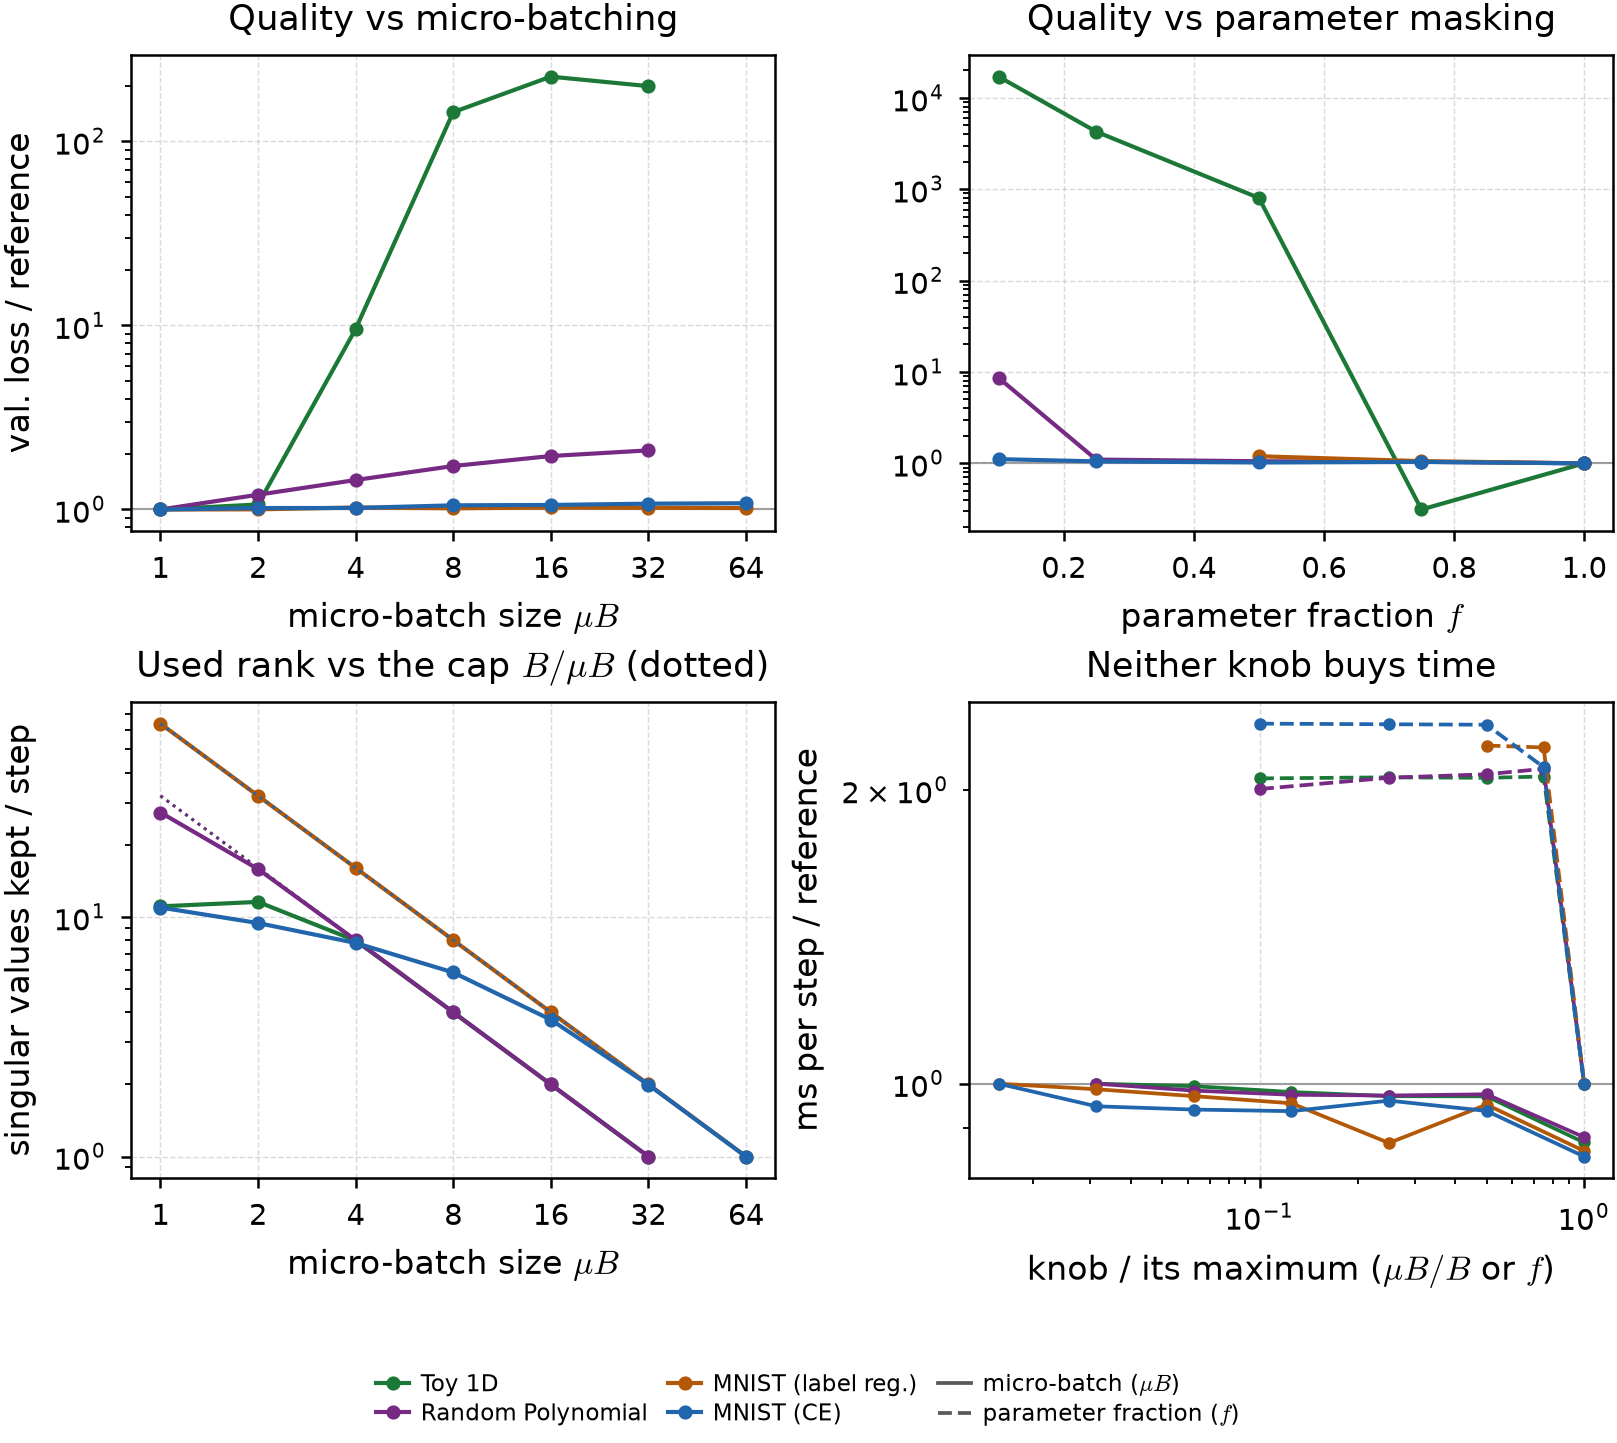

knobs: 5.39 x 4.81 in on the page (shown at 2x)


In [12]:
f = pf.make('knobs')
f.show(zoom=2)

In [13]:
# --- edit knobs -------------------------------------------------------
# its own knobs: arm_tick_fmt, aspect, cap_line, cap_lw, extra_h, family_proxies, fraction, legend_below, lw, ms, ncol, nrow, reference_line, style_fraction, tasks, time_lw, time_ms
# f = pf.make('knobs', arm_tick_fmt='{:.0f}', aspect=0.8, cap_line=True)
# f = pf.make('knobs', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('knobs', aspect=0.95)              # ... and make the CLI agree

## `overparam`

F5: the P/N sweep -- selected val. loss per task, then rank, reach, divergence

Its own knobs:

* `arm_tick_fmt` — default `'{:.2g}'`
* `aspect` — default `0.86`
* `extra_h` — default `0.5`
* `fraction` — default `0.3333333333333333`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 5, 'height': 0.5, 'fontsize': 5.2}`
* `lw` — default `1.0`
* `mark_partial_reach` — default `True`
* `mark_pn_one` — default `True`
* `min_log_sep` — default `0.12`
* `ms` — default `2.4`
* `ncol` — default `3`
* `nrow` — default `2`
* `other_lw` — default `0.75`
* `overlay_lw` — default `0.7`
* `overlay_ms` — default `2.0`
* `panel_legend` — default `{'fontsize': 5.0, 'loc': 'upper left', 'handlelength': 1.1}`
* `style_fraction` — default `0.32`
* `sven_lw` — default `1.25`
* `tasks` — default `['toy_1d', 'polynomial', 'mnist_labelreg']`
* `thin_ms` — default `2.2`


Loaded 3240 runs from ../experiment_results/_cache/rebuttal_overparam_toy_1d_scan.slim.pkl (slim cache)


Loaded 4320 runs from ../experiment_results/_cache/rebuttal_overparam_polynomial_scan.slim.pkl (slim cache)


Loaded 3600 runs from ../experiment_results/_cache/rebuttal_overparam_mnist_scan.slim.pkl (slim cache)


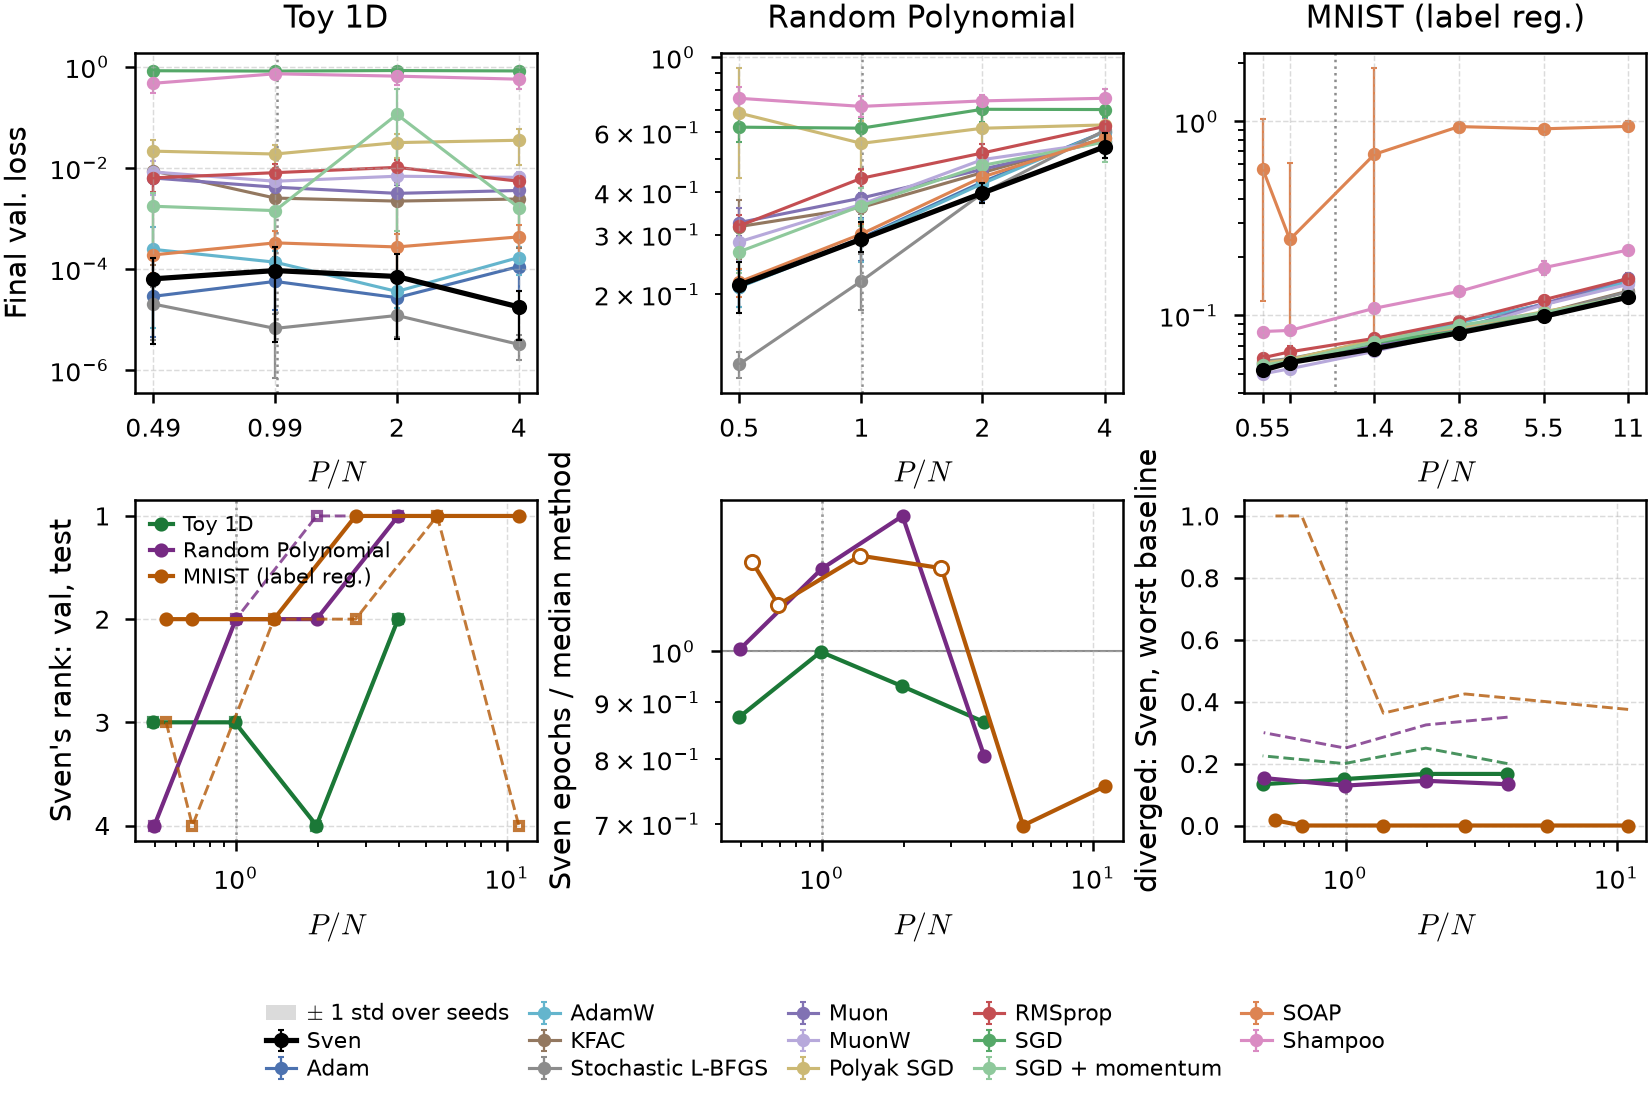

overparam: 5.50 x 3.65 in on the page (shown at 2x)


In [14]:
f = pf.make('overparam')
f.show(zoom=2)

In [15]:
# --- edit overparam -------------------------------------------------------
# its own knobs: arm_tick_fmt, aspect, extra_h, fraction, legend_below, lw, mark_partial_reach, mark_pn_one, min_log_sep, ms, ncol, nrow, other_lw, overlay_lw, overlay_ms, panel_legend, style_fraction, sven_lw, tasks, thin_ms
# f = pf.make('overparam', arm_tick_fmt='{:.2g}', aspect=0.86, extra_h=0.5)
# f = pf.make('overparam', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('overparam', aspect=0.95)              # ... and make the CLI agree

## `overparam_outcomes`

F5b: the same sweep read on test loss and on full-set train loss

Its own knobs:

* `arm_tick_fmt` — default `'{:.2g}'`
* `aspect` — default `0.86`
* `extra_h` — default `0.5`
* `fraction` — default `0.3333333333333333`
* `legend_below` — default `{'loc': 'lower center', 'frameon': False, 'ncol': 5, 'height': 0.5, 'fontsize': 5.2}`
* `mark_pn_one` — default `True`
* `metrics` — default `['final_test_loss', 'final_train_eval']`
* `min_log_sep` — default `0.12`
* `ncol` — default `3`
* `nrow` — default `2`
* `other_lw` — default `0.75`
* `style_fraction` — default `0.32`
* `sven_lw` — default `1.25`
* `tasks` — default `['toy_1d', 'polynomial', 'mnist_labelreg']`
* `thin_ms` — default `2.2`


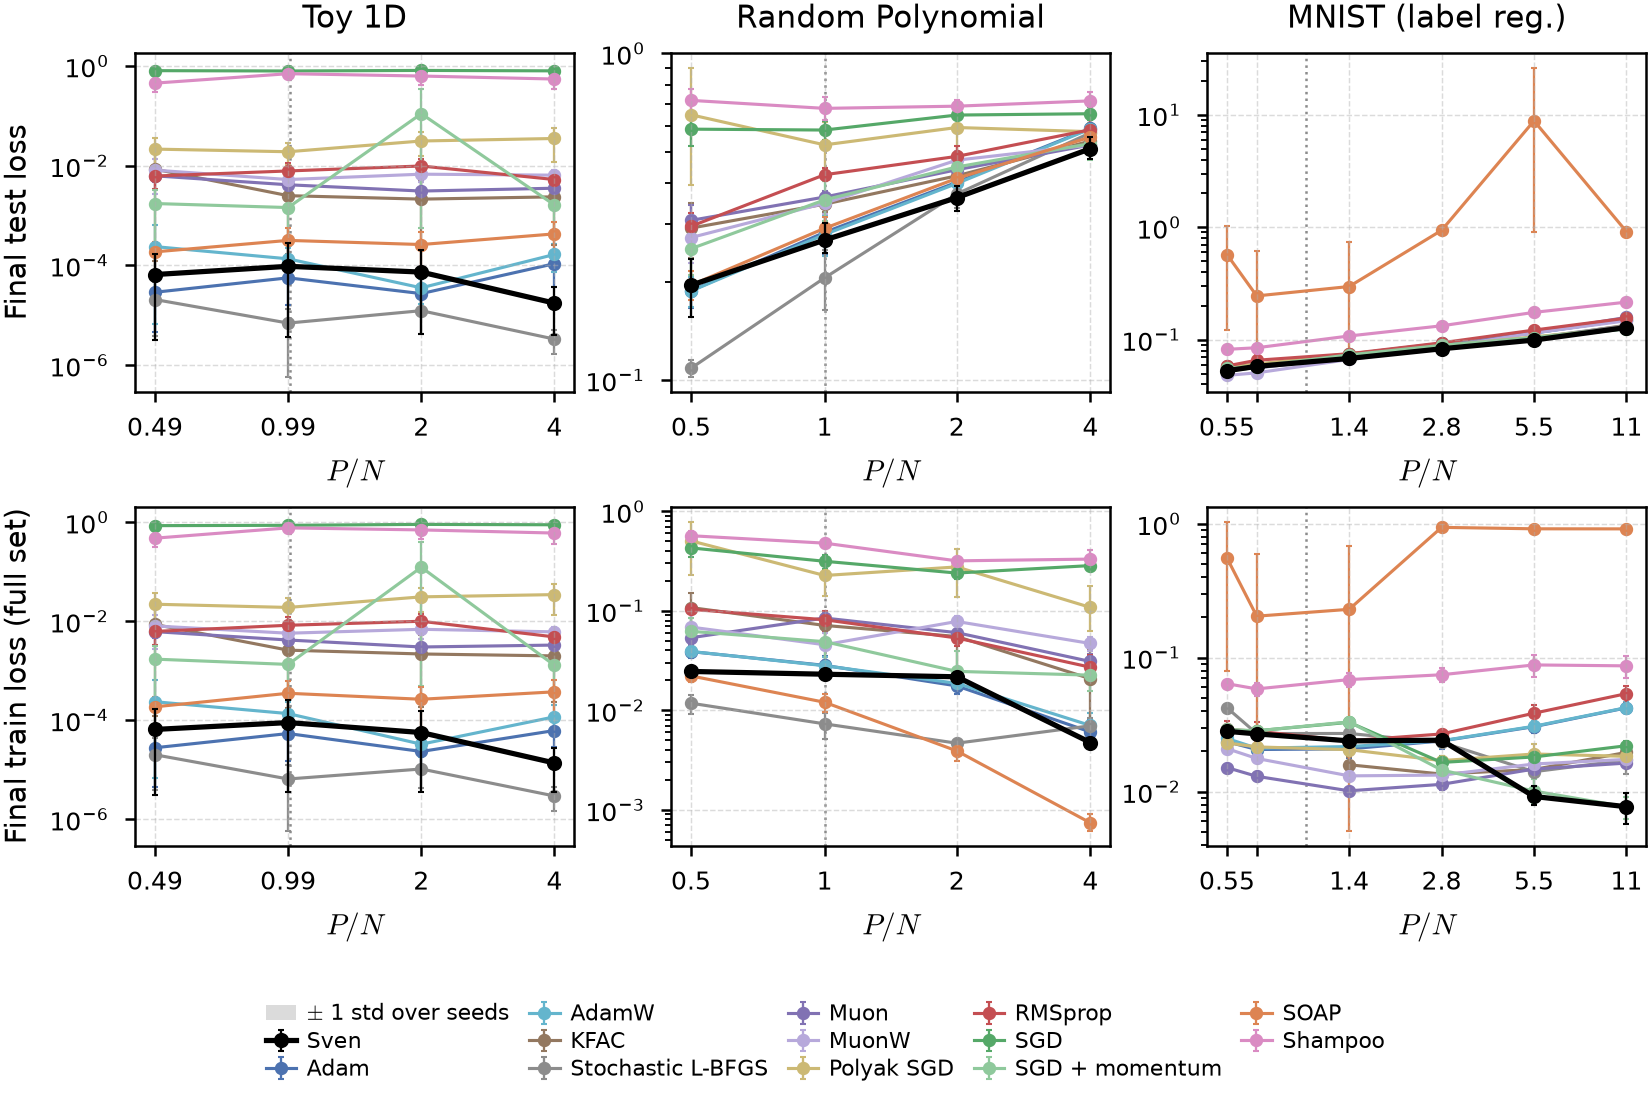

overparam_outcomes: 5.50 x 3.65 in on the page (shown at 2x)


In [16]:
f = pf.make('overparam_outcomes')
f.show(zoom=2)

In [17]:
# --- edit overparam_outcomes -------------------------------------------------------
# its own knobs: arm_tick_fmt, aspect, extra_h, fraction, legend_below, mark_pn_one, metrics, min_log_sep, ncol, nrow, other_lw, style_fraction, sven_lw, tasks, thin_ms
# f = pf.make('overparam_outcomes', arm_tick_fmt='{:.2g}', aspect=0.86, extra_h=0.5)
# f = pf.make('overparam_outcomes', aspect=0.95, legend={'loc': 'lower left', 'ncol': 6},
#             ylabel={0: 'Validation loss'})
# f.ax(0).set_xlabel('Epoch')               # ... or edit the objects directly
# f.show(zoom=2)
# f.save()                                   # write the paper PDF
# pf.pin('overparam_outcomes', aspect=0.95)              # ... and make the CLI agree

## What is pinned

Everything this notebook has pinned, i.e. what `python -m paper_assets` will replay. `pf.unpin(<name>)` drops one, `pf.unpin()` drops them all.

In [18]:
pf.pinned()

{}